In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# IMPORT LIBRARIES AND PROJECT PATHS

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

import joblib

# Project folders

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())


BASE_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids
DATA_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed
DATA_DIR exists: True


In [3]:
# CHECK PROCESSED DATA FILES

print("Processed files:")

for file in sorted(DATA_DIR.iterdir()):
    print("-", file.name)

Processed files:
- config
- models
- reports
- test_dedup.npz
- test_full.npz
- train_normal.npz
- val_normal.npz


In [4]:
# LOAD TRAIN / VALIDATION / TEST DATA

def load_npz(path):
    data = np.load(path)
    X = data["X"]
    y = data["y"] if "y" in data.files else None
    return X, y


X_train, _ = load_npz(DATA_DIR / "train_normal.npz")
X_val, _ = load_npz(DATA_DIR / "val_normal.npz")
X_test, y_test = load_npz(DATA_DIR / "test_full.npz")

print("Normal training data:", X_train.shape)
print("Normal validation data:", X_val.shape)
print("Full testing data:", X_test.shape)

if y_test is not None:
    print("Normal test records:", (y_test == 0).sum())
    print("Attack test records:", (y_test == 1).sum())


Normal training data: (41065, 41)
Normal validation data: (10266, 41)
Full testing data: (82332, 41)
Normal test records: 37000
Attack test records: 45332


In [5]:
# VERIFY INPUT DIMENSIONS AND DATA QUALITY

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], \
    "Feature dimensions do not match."

print("All datasets contain", X_train.shape[1], "model-input features.")

print("\nTraining minimum:", np.min(X_train))
print("Training maximum:", np.max(X_train))
print("Training mean:", np.mean(X_train))
print("Training standard deviation:", np.std(X_train))

print("\nAny NaN:", np.isnan(X_train).any())
print("Any infinity:", np.isinf(X_train).any())

All datasets contain 41 model-input features.

Training minimum: -3.388441571325508
Training maximum: 7.981187493058512
Training mean: 0.08408545533419882
Training standard deviation: 0.5488583224901848

Any NaN: False
Any infinity: False


In [6]:
# CREATE ONE-CLASS SVM MODEL

# Learns a boundary around normal traffic
# using an RBF kernel.

ocsvm_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.01,
    cache_size=4096,
    shrinking=True,
    tol=1e-3
)

print("One-Class SVM model created.")
print(ocsvm_model)

One-Class SVM model created.
OneClassSVM(cache_size=4096, nu=0.01)


In [7]:
# TRAIN OCSVM ON NORMAL DATA ONLY

print("Starting One-Class SVM training...")

ocsvm_model.fit(X_train)

print("OCSVM training completed.")
print("Training records:", X_train.shape[0])
print("Input features:", X_train.shape[1])
print("Number of support vectors:", len(ocsvm_model.support_))

Starting One-Class SVM training...
OCSVM training completed.
Training records: 41065
Input features: 41
Number of support vectors: 450


In [8]:
# CREATE OCSVM ANOMALY SCORES

# decision_function gives higher values for normal points
# and lower values for abnormal points.
# Reverse the sign so higher score means more anomalous.

def ocsvm_anomaly_scores(model, X):
    normality_score = model.decision_function(X)
    return -normality_score


train_scores = ocsvm_anomaly_scores(ocsvm_model, X_train)
val_scores = ocsvm_anomaly_scores(ocsvm_model, X_val)
test_scores = ocsvm_anomaly_scores(ocsvm_model, X_test)

print("Training scores:")
print("Mean:", train_scores.mean(), "Std:", train_scores.std())

print("\nValidation scores:")
print("Mean:", val_scores.mean(), "Std:", val_scores.std())

print("\nTest scores:")
print("Mean:", test_scores.mean(), "Std:", test_scores.std())

print("\nHigher OCSVM score = more anomalous.")

Training scores:
Mean: -6.1000773633889835 Std: 2.7801856841234587

Validation scores:
Mean: -6.064854316466841 Std: 2.773685018282413

Test scores:
Mean: -2.5077919421521004 Std: 5.831414619721436

Higher OCSVM score = more anomalous.


In [9]:
# CALIBRATE FALSE-POSITIVE BUDGET THRESHOLDS

# Use normal validation traffic to set the thresholds.

fp_budgets = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "3% budget": 0.03
}

thresholds = {}

for label, budget in fp_budgets.items():
    threshold = np.quantile(val_scores, 1 - budget)
    thresholds[label] = threshold

    val_predictions = (val_scores >= threshold).astype(int)
    validation_fpr = val_predictions.mean()

    print(
        f"{label}: "
        f"threshold={threshold:.8f}, "
        f"validation anomaly rate={validation_fpr:.4%}"
    )

0.5% budget: threshold=0.71522502, validation anomaly rate=0.5065%
1% budget: threshold=-0.00005331, validation anomaly rate=1.0033%
3% budget: threshold=-1.09146021, validation anomaly rate=3.0002%


In [10]:
# EVALUATION FUNCTION

def evaluate_threshold(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)

    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    actual_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_alerts_per_1000 = actual_fpr * 1000

    return {
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Actual FPR": actual_fpr,
        "False alerts per 1000": false_alerts_per_1000,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [11]:
# EVALUATE ALL FALSE-POSITIVE BUDGETS

evaluation_rows = []

for label, threshold in thresholds.items():
    metrics = evaluate_threshold(y_test, test_scores, threshold)
    metrics["Budget"] = label
    evaluation_rows.append(metrics)

ocsvm_budget_results = pd.DataFrame(evaluation_rows)

ocsvm_budget_results = ocsvm_budget_results[
    [
        "Budget",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Actual FPR",
        "False alerts per 1000",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(ocsvm_budget_results)

,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,TN,FP,FN,TP
0,0.5% budget,0.715225,0.907202,0.295663,0.445979,0.037054,37.054054,35629,1371,31929,13403
1,1% budget,-0.000053,0.893863,0.339606,0.492207,0.049405,49.405405,35172,1828,29937,15395
2,3% budget,-1.091460,0.872683,0.422615,0.569458,0.075541,75.540541,34205,2795,26174,19158


In [12]:
# ROC-AUC AND PR-AUC

ocsvm_roc_auc = roc_auc_score(y_test, test_scores)
ocsvm_pr_auc = average_precision_score(y_test, test_scores)

print(f"OCSVM ROC-AUC: {ocsvm_roc_auc:.4f}")
print(f"OCSVM PR-AUC: {ocsvm_pr_auc:.4f}")

OCSVM ROC-AUC: 0.7943
OCSVM PR-AUC: 0.8375


Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/ocsvm_budget_results.csv


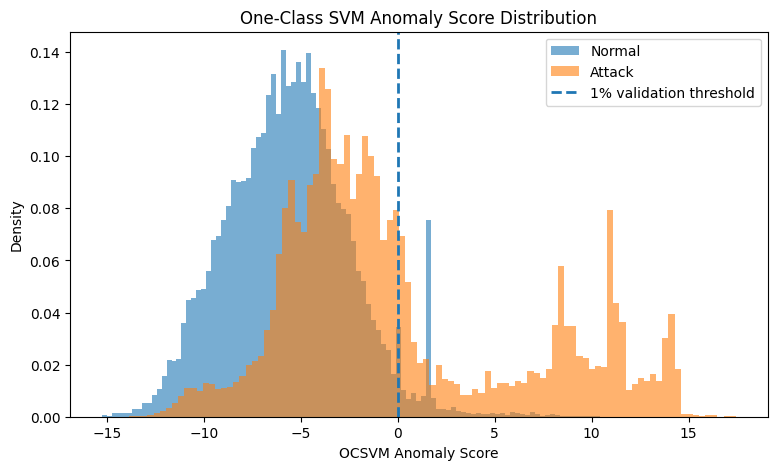

In [13]:
# SAVE BUDGET RESULTS

OCSVM_BUDGET_FILE = REPORT_DIR / "ocsvm_budget_results.csv"

ocsvm_budget_results.to_csv(
    OCSVM_BUDGET_FILE,
    index=False
)

print("Saved:", OCSVM_BUDGET_FILE)


# PLOT NORMAL VS ATTACK SCORES

normal_scores = test_scores[y_test == 0]
attack_scores = test_scores[y_test == 1]

plt.figure(figsize=(9, 5))

plt.hist(
    normal_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Normal"
)

plt.hist(
    attack_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Attack"
)

plt.axvline(
    thresholds["1% budget"],
    linestyle="--",
    linewidth=2,
    label="1% validation threshold"
)

plt.xlabel("OCSVM Anomaly Score")
plt.ylabel("Density")
plt.title("One-Class SVM Anomaly Score Distribution")
plt.legend()

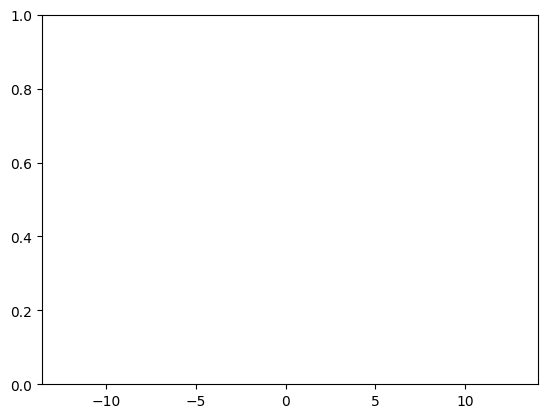

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/ocsvm_scores.png


In [14]:
# Limit extreme tails so the graph remains readable
plt.xlim(
    np.percentile(test_scores, 0.1),
    np.percentile(test_scores, 99)
)

OCSVM_SCORE_PLOT = REPORT_DIR / "ocsvm_scores.png"

plt.savefig(
    OCSVM_SCORE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", OCSVM_SCORE_PLOT)

In [15]:
# CREATE PREDICTIONS AT EACH BUDGET

threshold_005 = thresholds["0.5% budget"]
threshold_01 = thresholds["1% budget"]
threshold_03 = thresholds["3% budget"]

ocsvm_pred_005 = (test_scores >= threshold_005).astype(int)
ocsvm_pred_01 = (test_scores >= threshold_01).astype(int)
ocsvm_pred_03 = (test_scores >= threshold_03).astype(int)

In [16]:
# CREATE DASHBOARD-READY DATAFRAME

ocsvm_dashboard_results = pd.DataFrame({
    "record_id": range(1, len(test_scores) + 1),
    "actual_label": y_test,
    "actual_class": [
        "Attack" if y == 1 else "Normal"
        for y in y_test
    ],
    "ocsvm_score": test_scores,
    "ocsvm_prediction_0.5pct": ocsvm_pred_005,
    "ocsvm_prediction_1pct": ocsvm_pred_01,
    "ocsvm_prediction_3pct": ocsvm_pred_03,
    "ocsvm_status_0.5pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in ocsvm_pred_005
    ],
    "ocsvm_status_1pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in ocsvm_pred_01
    ],
    "ocsvm_status_3pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in ocsvm_pred_03
    ]
})

# Default dashboard operating point = 1%

ocsvm_dashboard_results["default_threshold"] = threshold_01
ocsvm_dashboard_results["default_prediction"] = ocsvm_pred_01

ocsvm_dashboard_results["default_status"] = [
    "Anomaly" if p == 1 else "Normal"
    for p in ocsvm_pred_01
]

ocsvm_dashboard_results["correct_prediction"] = (
    ocsvm_dashboard_results["default_prediction"]
    == ocsvm_dashboard_results["actual_label"]
)

display(ocsvm_dashboard_results.head(10))

,record_id,actual_label,actual_class,ocsvm_score,ocsvm_prediction_0.5pct,ocsvm_prediction_1pct,ocsvm_prediction_3pct,ocsvm_status_0.5pct,ocsvm_status_1pct,ocsvm_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,-5.218117,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
1,2,0,Normal,-1.407951,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
2,3,0,Normal,-3.566669,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
3,4,0,Normal,-6.754042,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
4,5,0,Normal,-3.339975,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
5,6,0,Normal,-5.622679,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
6,7,0,Normal,-2.716542,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
7,8,0,Normal,-3.306936,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
8,9,0,Normal,-0.000015,0,1,1,Normal,Anomaly,Anomaly,-0.000053,1,Anomaly,False
9,10,0,Normal,-0.000015,0,1,1,Normal,Anomaly,Anomaly,-0.000053,1,Anomaly,False


In [17]:
# SAVE DASHBOARD CSV

OCSVM_DASHBOARD_FILE = REPORT_DIR / "ocsvm_dashboard_results.csv"

ocsvm_dashboard_results.to_csv(
    OCSVM_DASHBOARD_FILE,
    index=False
)

print("OCSVM dashboard results saved:")
print(OCSVM_DASHBOARD_FILE)
print("Shape:", ocsvm_dashboard_results.shape)

display(ocsvm_dashboard_results.head(10))

OCSVM dashboard results saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/ocsvm_dashboard_results.csv
Shape: (82332, 14)


,record_id,actual_label,actual_class,ocsvm_score,ocsvm_prediction_0.5pct,ocsvm_prediction_1pct,ocsvm_prediction_3pct,ocsvm_status_0.5pct,ocsvm_status_1pct,ocsvm_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,-5.218117,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
1,2,0,Normal,-1.407951,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
2,3,0,Normal,-3.566669,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
3,4,0,Normal,-6.754042,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
4,5,0,Normal,-3.339975,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
5,6,0,Normal,-5.622679,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
6,7,0,Normal,-2.716542,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
7,8,0,Normal,-3.306936,0,0,0,Normal,Normal,Normal,-0.000053,0,Normal,True
8,9,0,Normal,-0.000015,0,1,1,Normal,Anomaly,Anomaly,-0.000053,1,Anomaly,False
9,10,0,Normal,-0.000015,0,1,1,Normal,Anomaly,Anomaly,-0.000053,1,Anomaly,False


In [18]:
# DEFAULT 1% BUDGET RESULT

default_result = ocsvm_budget_results[
    ocsvm_budget_results["Budget"] == "1% budget"
]

print("OCSVM DEFAULT OPERATING POINT")
print("=============================")

display(default_result)

print(f"ROC-AUC: {ocsvm_roc_auc:.4f}")
print(f"PR-AUC: {ocsvm_pr_auc:.4f}")

OCSVM DEFAULT OPERATING POINT


,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,TN,FP,FN,TP
1,1% budget,-0.000053,0.893863,0.339606,0.492207,0.049405,49.405405,35172,1828,29937,15395


ROC-AUC: 0.7943
PR-AUC: 0.8375


In [19]:
# SAVE OCSVM MODEL

OCSVM_MODEL_FILE = MODEL_DIR / "ocsvm_model.joblib"

joblib.dump(ocsvm_model, OCSVM_MODEL_FILE)

print("Saved OCSVM model:")
print(OCSVM_MODEL_FILE)

Saved OCSVM model:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/models/ocsvm_model.joblib


In [20]:
# SAVE OCSVM CONFIGURATION

OCSVM_CONFIG_FILE = CONFIG_DIR / "ocsvm_model.json"

ocsvm_information = {
    "model": "One-Class SVM",
    "model_type": "Unsupervised comparison model",
    "purpose": "Network anomaly detection",
    "training_data": "train_normal.npz",
    "validation_data": "val_normal.npz",
    "test_data": "test_full.npz",
    "training_strategy": "Normal-only training",
    "input_features": int(X_train.shape[1]),
    "kernel": "rbf",
    "gamma": "scale",
    "nu": 0.01,
    "score_direction": "Higher score means more anomalous",
    "score_definition": "negative of sklearn OneClassSVM decision_function",
    "roc_auc": float(ocsvm_roc_auc),
    "pr_auc": float(ocsvm_pr_auc),
    "support_vectors": int(len(ocsvm_model.support_)),
    "thresholds": {
        label: float(value)
        for label, value in thresholds.items()
    }
}

with open(OCSVM_CONFIG_FILE, "w") as f:
    json.dump(ocsvm_information, f, indent=4)

print("Saved configuration:")
print(OCSVM_CONFIG_FILE)

Saved configuration:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/ocsvm_model.json


In [21]:
# VERIFY OUTPUT FILES

files_to_check = [
    OCSVM_MODEL_FILE,
    OCSVM_CONFIG_FILE,
    OCSVM_BUDGET_FILE,
    OCSVM_DASHBOARD_FILE,
    OCSVM_SCORE_PLOT
]

print("\nOCSVM implementation completed.")

for file in files_to_check:
    print(file.name, "->", file.exists())

print("\nFiles created:")
print("1. ocsvm_model.joblib")
print("2. ocsvm_model.json")
print("3. ocsvm_budget_results.csv")
print("4. ocsvm_dashboard_results.csv")
print("5. ocsvm_scores.png")


OCSVM implementation completed.
ocsvm_model.joblib -> True
ocsvm_model.json -> True
ocsvm_budget_results.csv -> True
ocsvm_dashboard_results.csv -> True
ocsvm_scores.png -> True

Files created:
1. ocsvm_model.joblib
2. ocsvm_model.json
3. ocsvm_budget_results.csv
4. ocsvm_dashboard_results.csv
5. ocsvm_scores.png


In [22]:
# CREATE OCSVM ZIP PACKAGE

import zipfile
from google.colab import files

OCSVM_ZIP_FILE = "/content/OCSVM_Results.zip"

files_to_zip = [
    OCSVM_MODEL_FILE,
    OCSVM_CONFIG_FILE,
    OCSVM_BUDGET_FILE,
    OCSVM_DASHBOARD_FILE,
    OCSVM_SCORE_PLOT
]

with zipfile.ZipFile(OCSVM_ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_zip:
        if file_path.exists():
            zipf.write(file_path, arcname=file_path.name)
            print("Added:", file_path.name)
        else:
            print("Missing:", file_path)

print("\nOCSVM package created successfully:")
print(OCSVM_ZIP_FILE)

files.download(OCSVM_ZIP_FILE)

Added: ocsvm_model.joblib
Added: ocsvm_model.json
Added: ocsvm_budget_results.csv
Added: ocsvm_dashboard_results.csv
Added: ocsvm_scores.png

OCSVM package created successfully:
/content/OCSVM_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>